In [1]:
from os import makedirs

import pandas as pd
import matplotlib.pyplot as plt

from plot_helpers import *

OUTPUT_DIR = '01_output'
makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv('data/enrollments.csv', low_memory=False)

# Clean malformed country names (extra quotes)
df['country'] = df['country'].str.replace('"', '').str.strip()

# Drop rows that are effectively empty header rows (no year value)
df = df.dropna(subset=['year'])

# Convert coordinate strings to numeric where possible
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# iau_id1 is the identifier in the prompt
# students5_estimated is the enrollment number from the prompt
drop_cols = [
    'iau_id',
    'students5_interpolated',
    'students5_extrapolated'
]
df.drop(columns=drop_cols, inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Year range: {int(df['year'].min())} – {int(df['year'].max())}")
print(f"Unique institutions: {df['iau_id1'].nunique()}")
print(f"Unique countries: {df['country'].nunique()}")

Shape after cleaning: (161525, 24)
Year range: 1950 – 2020
Unique institutions: 17833
Unique countries: 194


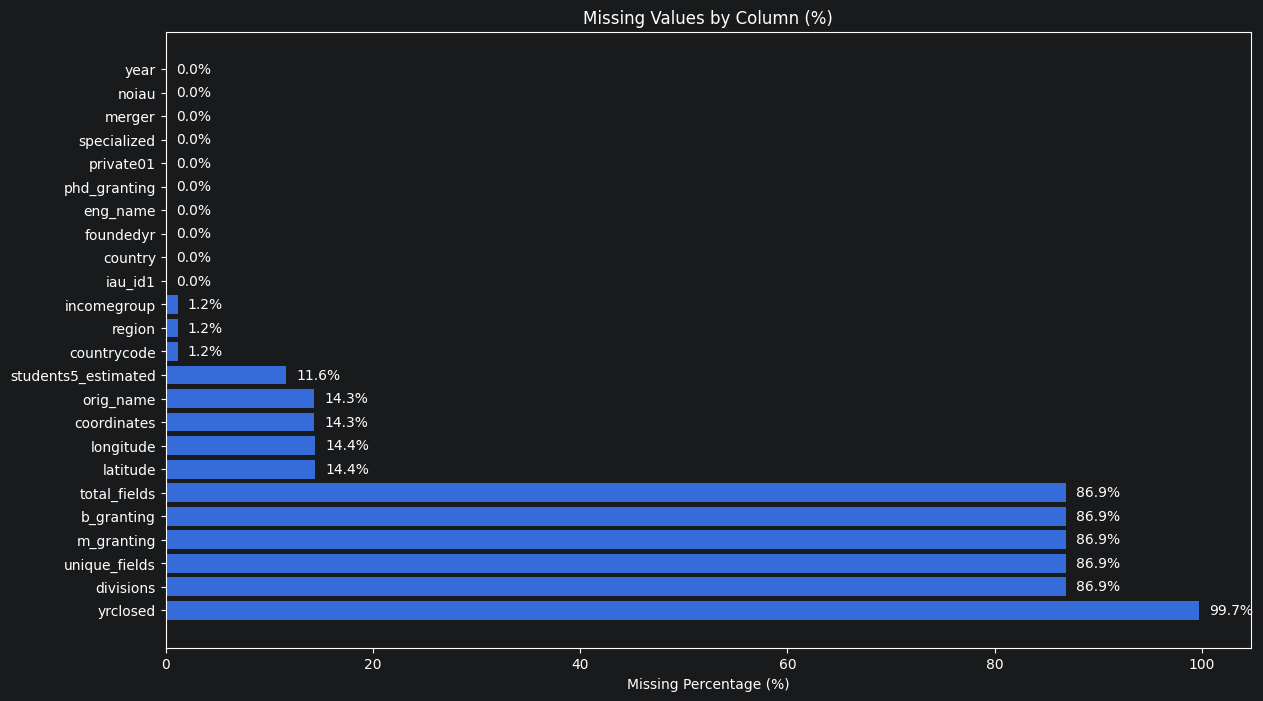

In [2]:
# look at missingness

values = df.isnull().mean().sort_values(ascending=False) * 100
labels = values.index
values = values.values

fig, ax = plt.subplots(figsize=(14, 8))

plot_barh(values, labels, ax=ax, title='Missing Values by Column (%)', xlabel='Missing Percentage (%)', formater=lambda x: f'{x:.1f}%')

plt.savefig(f'{OUTPUT_DIR}/01_missing_values.png')
plt.show()


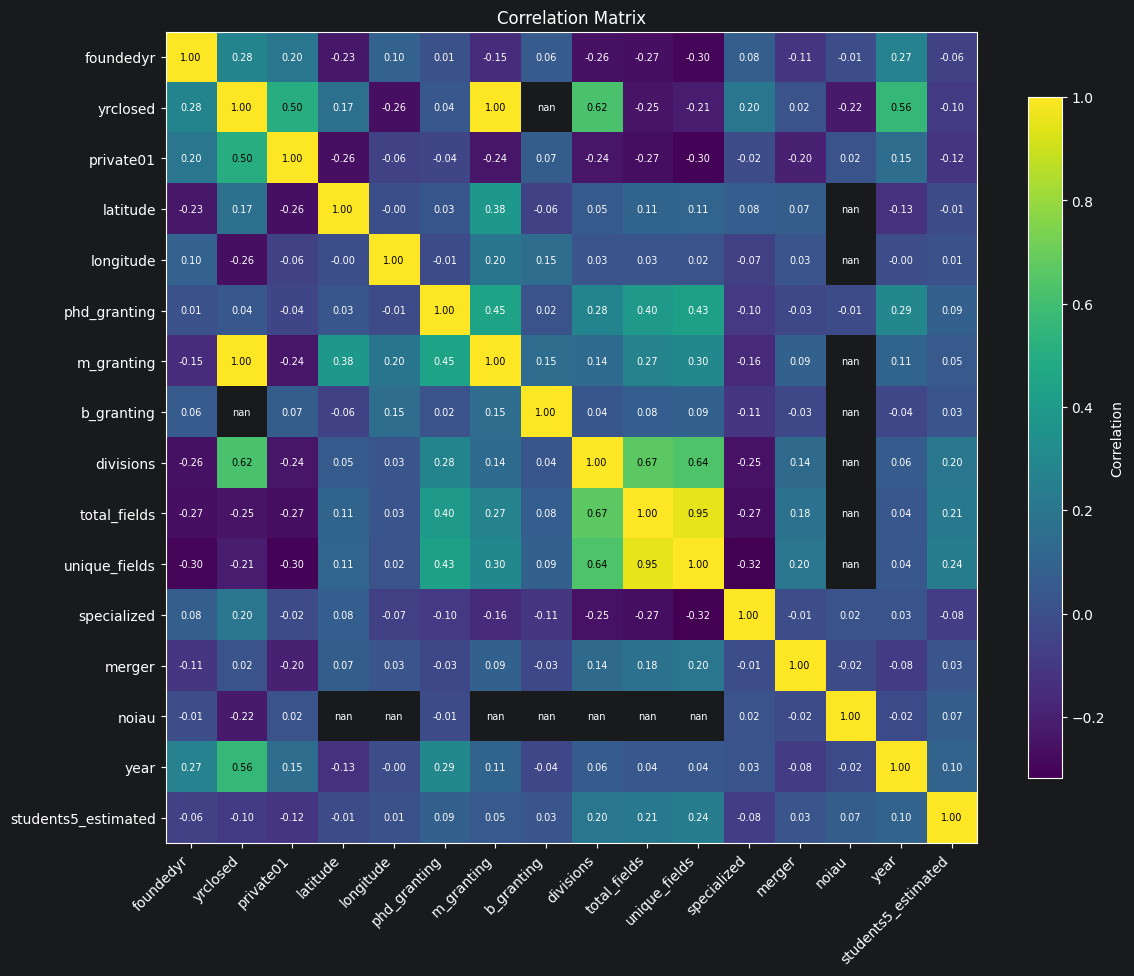

In [3]:
# Correlation heatmap

fig, ax = plt.subplots(figsize=(12, 10))

numeric_cols = ['foundedyr', 'yrclosed', 'private01', 'latitude', 'longitude',
                'phd_granting', 'm_granting', 'b_granting', 'divisions',
                'total_fields', 'unique_fields', 'specialized', 'merger', 'noiau',
                'year',  'students5_estimated']
corr = df[numeric_cols].corr()

# Render lower-triangle heatmap with imshow
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Annotate lower triangle
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text_color = 'black' if abs(corr.values[i, j]) > 0.5 else 'white'
        ax.text(j, i, f'{corr.values[i, j]:.2f}',
                ha='center', va='center', color=text_color, fontsize=7)

ax.set_title('Correlation Matrix')
fig.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_correlation_heatmap.png')
plt.show()

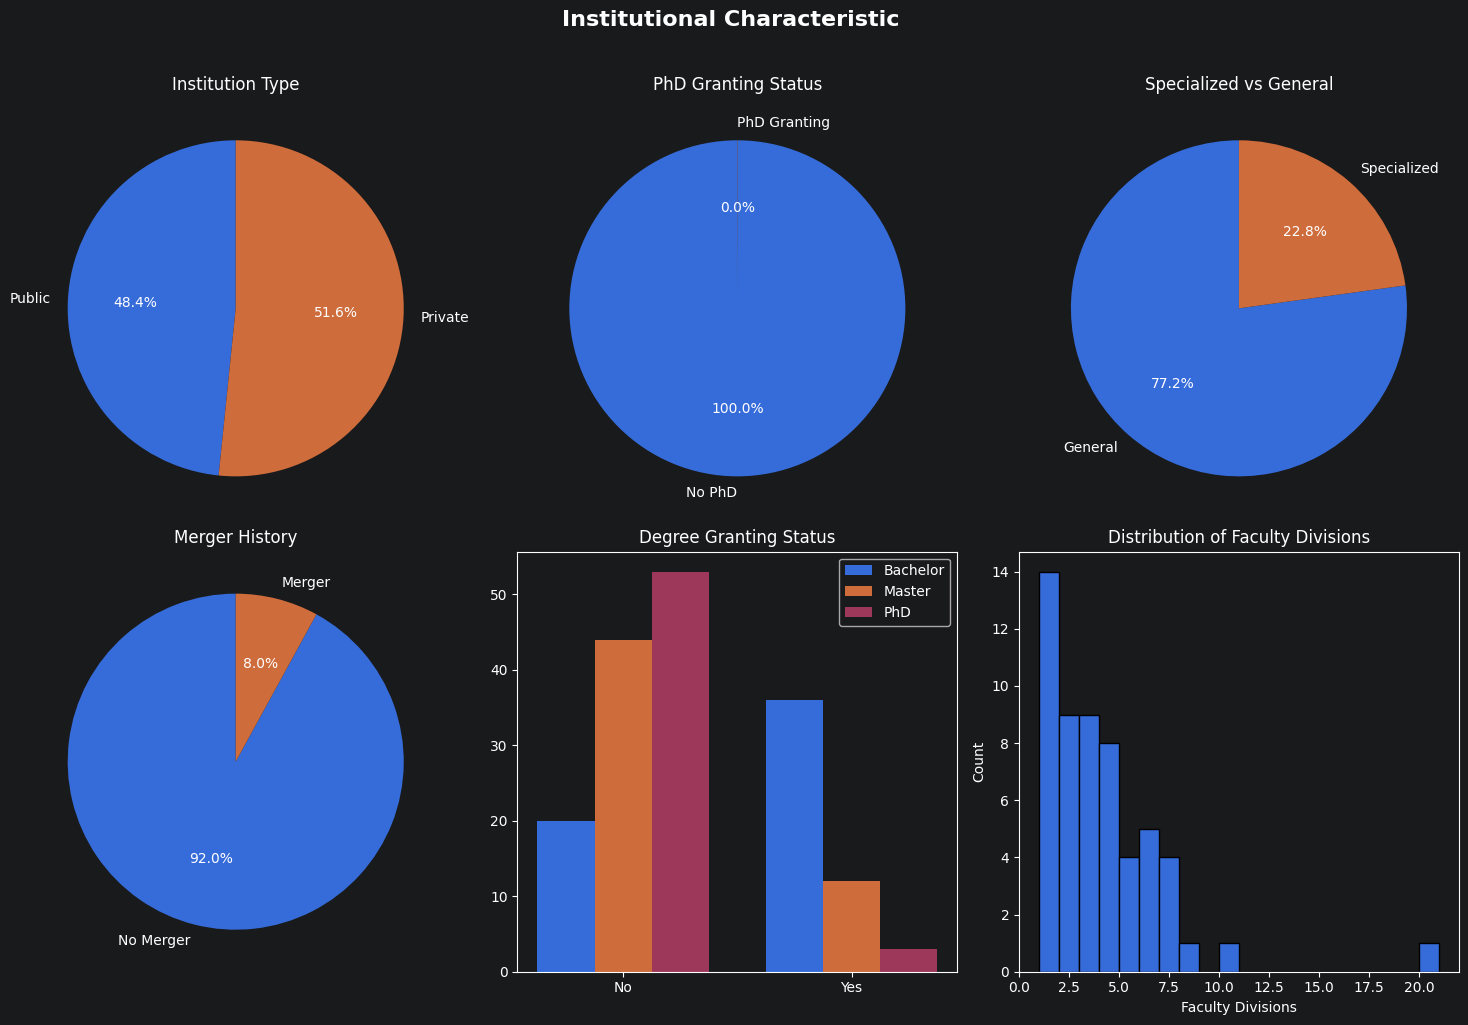

In [4]:
# Institution level characteristics
# looking at most recent data pre-2020 (schema states some fields are dropped in 2020)

df_recent = df.loc[df['year'] < 2020, :] \
       .sort_values(by=['iau_id1', 'year'], ascending=True) \
       .drop_duplicates(subset=['iau_id1'], keep='first') \
       .reset_index(drop=True)

plots = {}

# Private vs Public
values = df_recent['private01'].value_counts().sort_index()
plots['Private vs Public'] = {
    'idx': (0,0),
    'type': plot_pie,
    'args': [
        values.values,
        ["Public", "Private"],
    ],
    'kwargs': {
        'title': 'Institution Type'
    }
}

# PhD Granting
values = df_recent['phd_granting'].value_counts().sort_index()
plots['PhD Granting'] = {
    'idx': (0,1),
    'type': plot_pie,
    'args': [
        values.values,
        ['No PhD', 'PhD Granting'],
    ],
    'kwargs': {
        'title': 'PhD Granting Status'
    }
}

# Specialized
values = df_recent['specialized'].value_counts().sort_index()
plots['Specialized'] = {
    'idx': (0,2),
    'type': plot_pie,
    'args': [
        values.values,
        ['General', 'Specialized'],
    ],
    'kwargs': {
        'title': 'Specialized vs General'
    }
}

# Merger
values = df_recent['merger'].value_counts().sort_index()
plots['Merger'] = {
    'idx': (1,0),
    'type': plot_pie,
    'args': [
        values.values,
        ['No Merger', 'Merger'],
    ],
    'kwargs': {
        'title': 'Merger History'
    },
}

# Degree granting (subset with data)
deg = df_recent.dropna(subset=['b_granting', 'm_granting'])
deg_summary = {
    'Bachelor': deg['b_granting'].value_counts().sort_index(),
    'Master': deg['m_granting'].value_counts().sort_index(),
    'PhD': deg['phd_granting'].value_counts().sort_index()
}
plots['Degree Granting'] = {
    'idx': (1,1),
    'type': plot_2g_bar,
    'args': [
        deg_summary,
    ],
    'kwargs': {
        'title': 'Degree Granting Status',
        'xticklabels': ['No', 'Yes'],
    }
}

# Faculty divisions
values = deg['divisions'].dropna()
plots['Faculty Divisions'] = {
    'idx': (1,2),
    'type': plot_hist,
    'args': [
        values.values,
    ],
    'kwargs': {
        'title': 'Distribution of Faculty Divisions',
        'xlabel': 'Faculty Divisions',
        'ylabel': 'Count',
        'bins': 20,
    }
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for _, plot_info in plots.items():
    idx = plot_info['idx']
    plot_type = plot_info['type']
    args = plot_info['args']
    kwargs = plot_info['kwargs']

    plot_type(*args, axes[*idx], **kwargs)

plt.suptitle('Institutional Characteristic', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_institutional_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

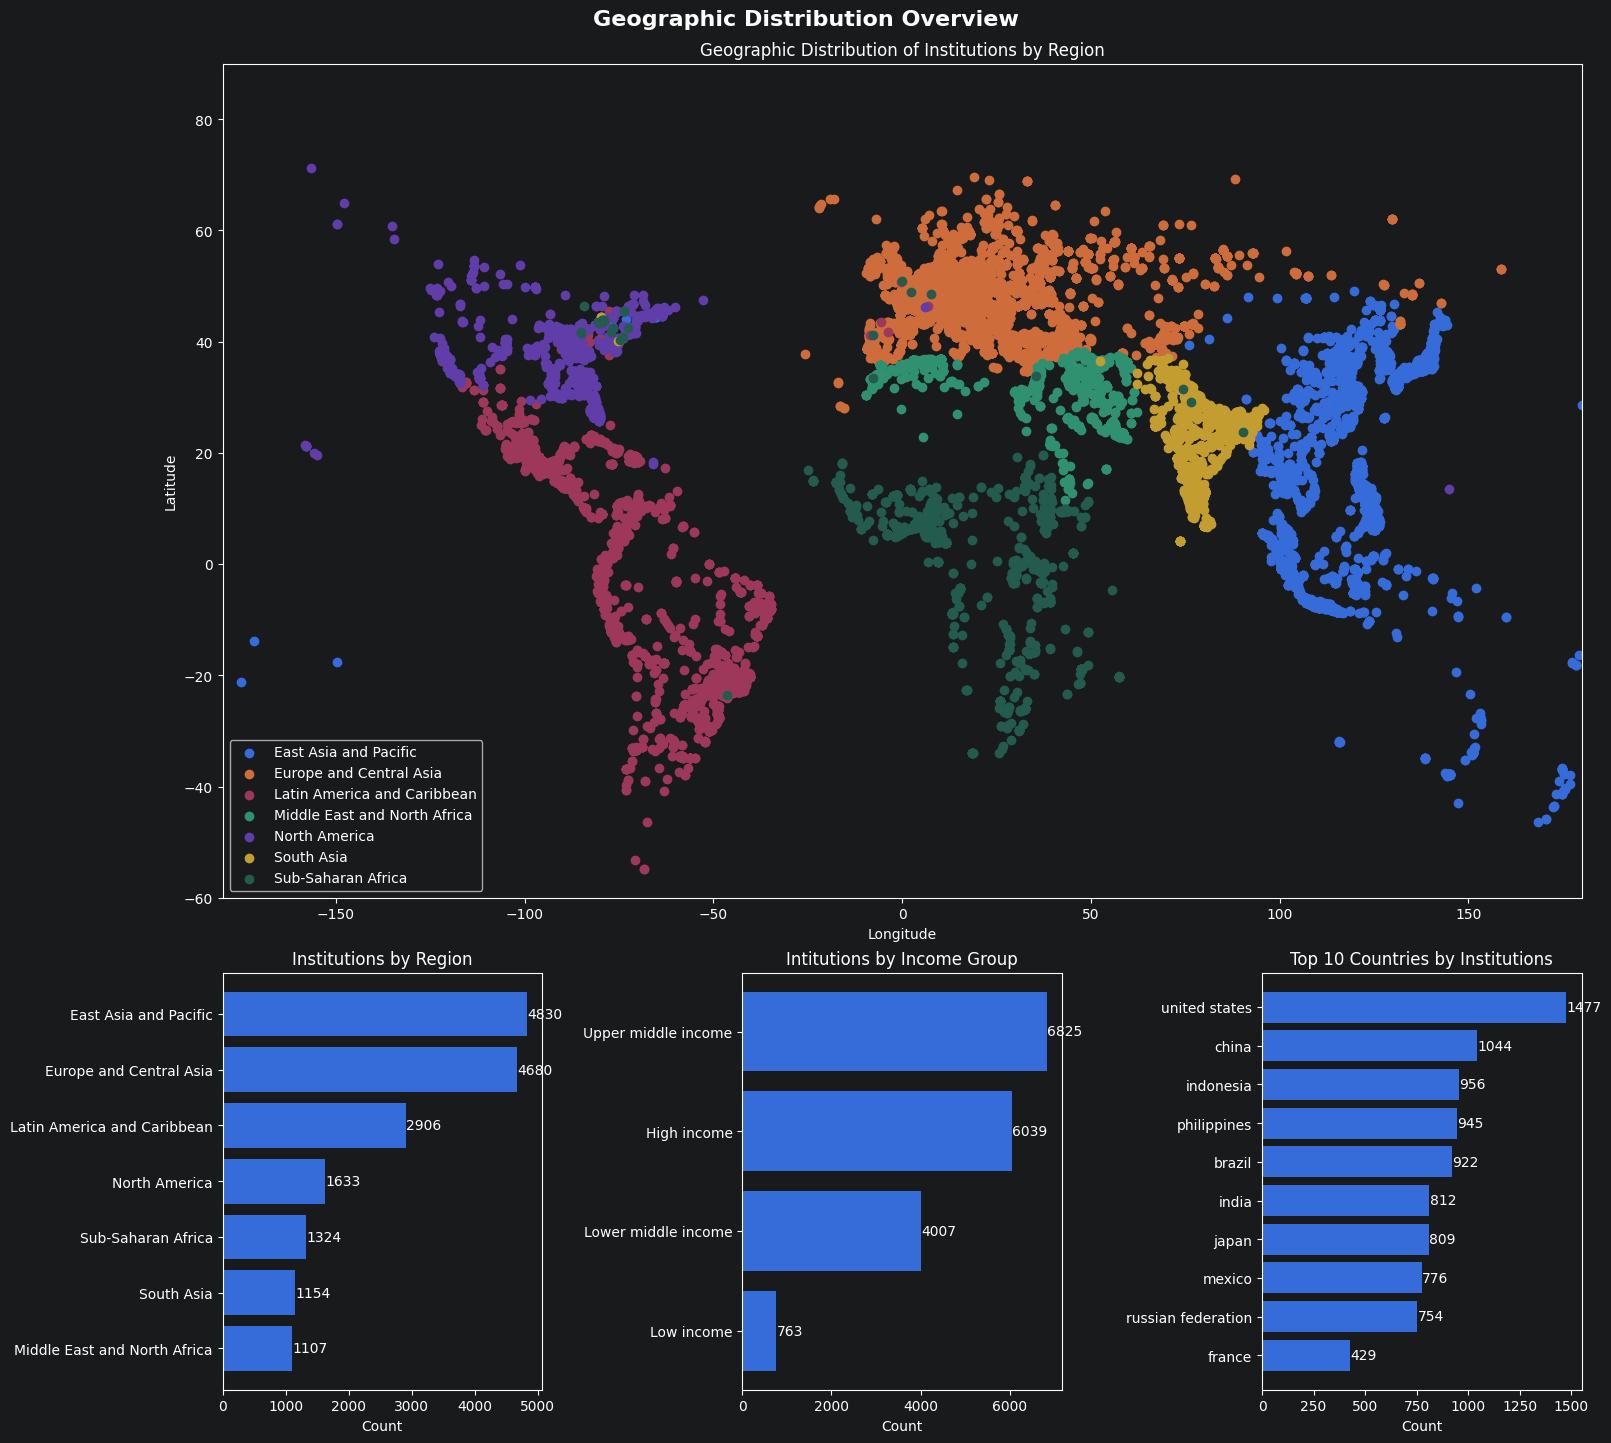

In [5]:
# Geographic distribution (most recent entries)

plots = {}

# Region counts
region_counts = df_recent['region'].value_counts()[::-1]
plots['Region Counts'] = {
    'idx': 0,
    'type': plot_barh,
    'args': [
        region_counts.values,
        region_counts.index,
    ],
    'kwargs': {
        'title': 'Institutions by Region',
        'xlabel': 'Count',
    }
}

income_counts = df_recent['incomegroup'].value_counts()[::-1]
plots['Income Group Counts'] = {
    'idx': 1,
    'type': plot_barh,
    'args': [
        income_counts.values,
        income_counts.index,
    ],
    'kwargs': {
        'title': 'Intitutions by Income Group',
        'xlabel': 'Count',
    }
}

countries = df_recent['country'].value_counts().head(10)[::-1]
plots['Top 10 Countries'] = {
    'idx': 2,
    'type': plot_barh,
    'args': [
        countries.values,
        countries.index,
    ],
    'kwargs': {
        'title': 'Top 10 Countries by Institutions',
        'xlabel': 'Count',
    }
}

gb = df_recent.groupby('region')
geo = {region: [sub_df_recent['longitude'], sub_df_recent['latitude']]
       for region, sub_df_recent in gb}
plots['Geographic Distribution'] = {
    'idx': 3,
    'type': plot_scatter,
    'args': [
        geo
    ],
    'kwargs': {
        'title': 'Geographic Distribution of Institutions by Region',
        'xlabel': 'Longitude',
        'ylabel': 'Latitude',
        'xlim': (-180, 180),
        'ylim': (-60, 90),
    }
}

fig, axes = plt.subplot_mosaic([[3, 3, 3], [3, 3, 3], [0, 1, 2]],
                              layout='constrained',
                               figsize=(16, 14))

for _, plot_info in plots.items():
    idx = plot_info['idx']
    plot_type = plot_info['type']
    args = plot_info['args']
    kwargs = plot_info['kwargs']

    plot_type(*args, axes[idx], **kwargs)

plt.suptitle('Geographic Distribution Overview', fontsize=16, fontweight='bold', y=1.02)
plt.savefig(f'{OUTPUT_DIR}/04_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

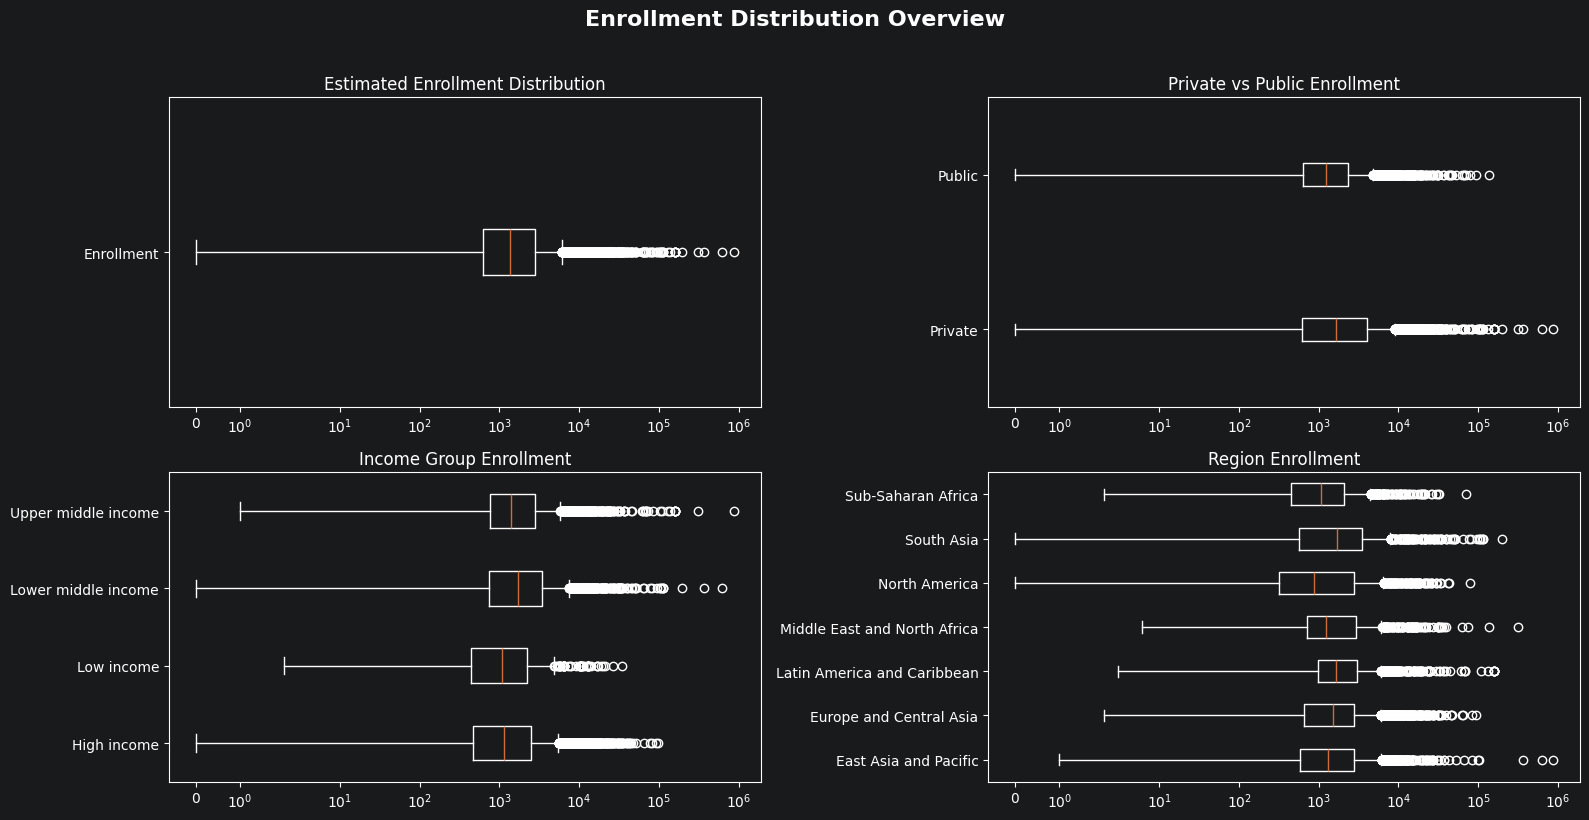

In [6]:
# Enrollment estimates

plots = {}

# Overall enrollment
values = df_recent.loc[:, ['iau_id1','students5_estimated']].dropna()['students5_estimated']
plots['Estimated Enrollment'] = {
    'idx': (0,0),
    'type': plot_hbox,
    'args': [
        {"Enrollment": values.values}
    ],
    'kwargs': {
        'title': 'Estimated Enrollment Distribution',
    }
}

# Private/Public enrollment
values = df_recent.loc[:, ['iau_id1','private01', 'students5_estimated']].dropna()
gb = values.groupby('private01')
plots['Private vs Public Enrollment'] = {
    'idx': (0,1),
    'type': plot_hbox,
    'args': [
        {
            'Private': gb.get_group(0)['students5_estimated'].values,
            'Public': gb.get_group(1)['students5_estimated'].values,
        }
    ],
    'kwargs': {
        'title': 'Private vs Public Enrollment',
    }
}

# Income enrollment
values = df_recent.loc[:, ['iau_id1','incomegroup', 'students5_estimated']].dropna()
gb = values.groupby('incomegroup')
groups = {income: sub_df['students5_estimated'].values for income, sub_df in gb}
plots['Income Group Enrollment'] = {
    'idx': (1,0),
    'type': plot_hbox,
    'args': [
        groups
    ],
    'kwargs': {
        'title': 'Income Group Enrollment',
    }
}

# Region enrollment
values = df_recent.loc[:, ['iau_id1','region', 'students5_estimated']].dropna()
gb = values.groupby('region')
groups = {region: sub_df['students5_estimated'].values for region, sub_df in gb}
plots['Region Enrollment'] = {
    'idx': (1,1),
    'type': plot_hbox,
    'args': [
        groups
    ],
    'kwargs': {
        'title': 'Region Enrollment',
    }
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for _, plot_info in plots.items():
    idx = plot_info['idx']
    plot_type = plot_info['type']
    args = plot_info['args']
    kwargs = plot_info['kwargs']

    plot_type(*args, axes[idx], **kwargs)
    axes[*idx].set_xscale('symlog')


plt.suptitle('Enrollment Distribution Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_enrollment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

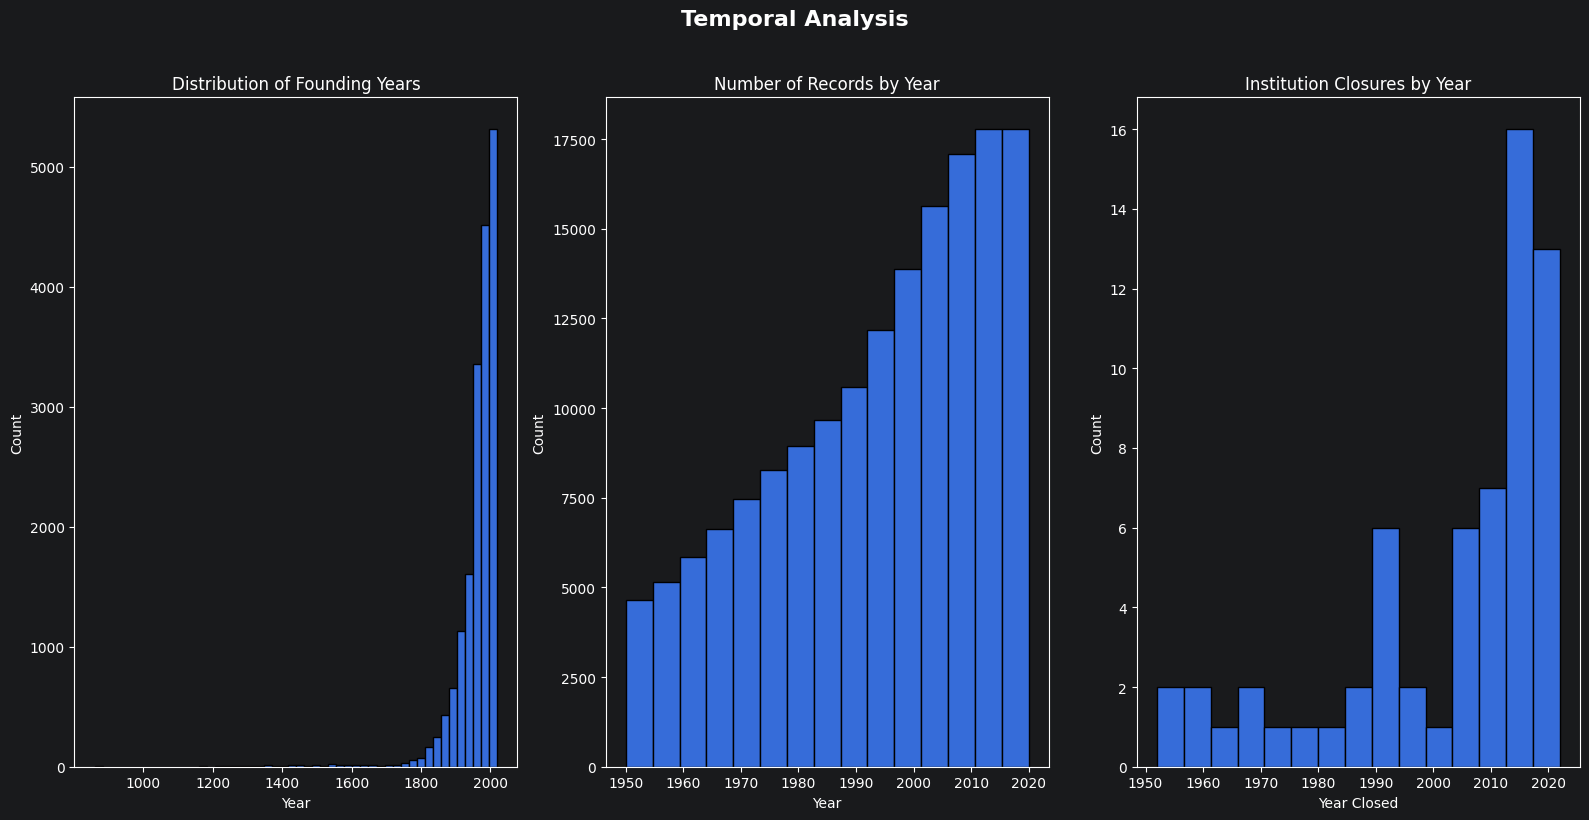

In [7]:
 # Temporal plots by institution

plots = {}

# Founding Years
inst_founded = df.drop_duplicates(subset=['iau_id1'])[['iau_id1', 'foundedyr']].copy()
plots['Founding Years'] = {
    'idx': 0,
    'type': plot_hist,
    'args': [
        inst_founded['foundedyr'].values,
    ],
    'kwargs': {
        'title': 'Distribution of Founding Years',
        'xlabel': 'Year',
        'ylabel': 'Count',
        'bins': 50,
    }
}

# Records by Year
yc = df['year']
plots['Number of Records by Year'] = {
    'idx': 1,
    'type': plot_hist,
    'args': [
        yc.values,
    ],
    'kwargs': {
        'title': 'Number of Records by Year',
        'xlabel': 'Year',
        'ylabel': 'Count',
        'bins': 15,
    }
}

# Years of Closure
closed = df[df['yrclosed'].notna()].drop_duplicates(subset=['iau_id1'])['yrclosed']
plots['Institution Closures by Year'] = {
    'idx': 2,
    'type': plot_hist,
    'args': [
        closed.values,
    ],
    'kwargs': {
        'title': 'Institution Closures by Year',
        'xlabel': 'Year Closed',
        'ylabel': 'Count',
        'bins': 15,
    }
}

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

for _, plot_info in plots.items():
    idx = plot_info['idx']
    plot_type = plot_info['type']
    args = plot_info['args']
    kwargs = plot_info['kwargs']

    plot_type(*args, axes[idx], **kwargs)


plt.suptitle('Temporal Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

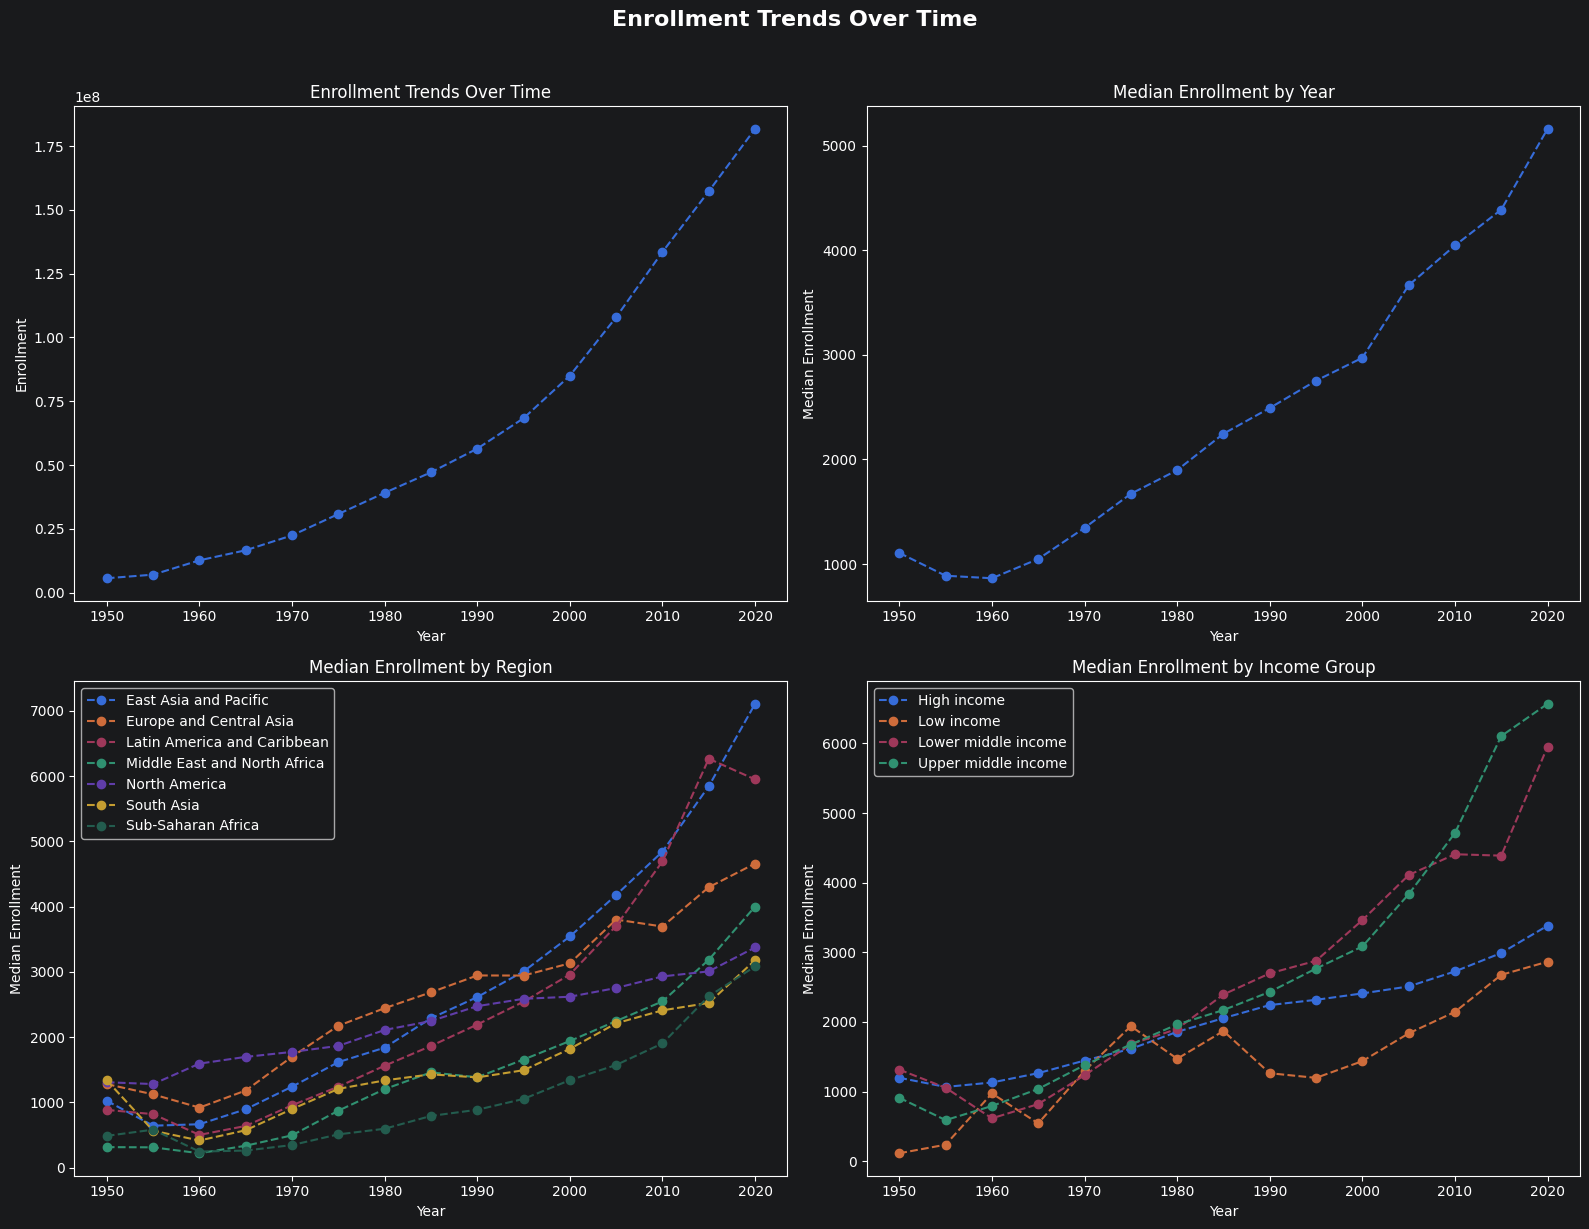

In [8]:
# Enrollment trends

plots = {}

# Estimated enrollment by year
yearly = df.groupby('year').agg({
    'students5_estimated': 'sum',
})
plots['Enrollment Trends'] = {
    'idx': (0,0),
    'type': plot_lines,
    'args': [
        {'Yearly': [yearly.index, yearly['students5_estimated'].values]},
    ],
    'kwargs': {
        'title': 'Enrollment Trends Over Time',
        'xlabel': 'Year',
        'ylabel': 'Enrollment',
    }
}

# Median enrollment by year
ym = df.groupby('year').agg({
    'students5_estimated': 'median',
})
plots['Median Enrollment by Year'] = {
    'idx': (0,1),
    'type': plot_lines,
    'args': [
        {'Yearly': [ym.index, ym['students5_estimated'].values]},
    ],
    'kwargs': {
        'title': 'Median Enrollment by Year',
        'xlabel': 'Year',
        'ylabel': 'Median Enrollment',
    }
}

# Median enrollment by region
rd = df.groupby(['region', 'year']).agg({
    'students5_estimated': 'median',
}).reset_index()
groups = {region: [sub_df['year'], sub_df['students5_estimated']]
          for region, sub_df in rd.groupby('region')}
plots['Median Enrollment by Region'] = {
    'idx': (1,0),
    'type': plot_lines,
    'args': [
        groups,
    ],
    'kwargs': {
        'title': 'Median Enrollment by Region',
        'xlabel': 'Year',
        'ylabel': 'Median Enrollment',
    }
}

# Median enrollment by income group
ig = df.groupby(['incomegroup', 'year']).agg({
    'students5_estimated': 'median',
}).reset_index()
groups = {region: [sub_df['year'], sub_df['students5_estimated']]
          for region, sub_df in ig.groupby('incomegroup')}
plots['Median Enrollment by Income Group'] = {
    'idx': (1,1),
    'type': plot_lines,
    'args': [
        groups,
    ],
    'kwargs': {
        'title': 'Median Enrollment by Income Group',
        'xlabel': 'Year',
        'ylabel': 'Median Enrollment',
    }
}


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for _, plot_info in plots.items():
    idx = plot_info['idx']
    plot_type = plot_info['type']
    args = plot_info['args']
    kwargs = plot_info['kwargs']

    plot_type(*args, axes[idx], **kwargs)

plt.suptitle('Enrollment Trends Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_enrollment_trends.png', dpi=150, bbox_inches='tight')
plt.show()